# Лабораторная работа №1
## Нейрон с нуля: градиентный спуск, обратное распространение ошибки, классификация Iris

### Цели работы:
1. Реализовать искусственный нейрон с сигмоидной функцией активации
2. Реализовать многослойную нейронную сеть (MLP) с градиентным спуском и backprop
3. Решить задачу классификации датасета Iris одним нейроном и сетью (2 слоя × 10 нейронов)
4. Отрисовать разделяющие линии, сравнить метрики

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

---
## Часть 1. Реализация нейронной сети с нуля

### 1.1 Функции активации и их производные

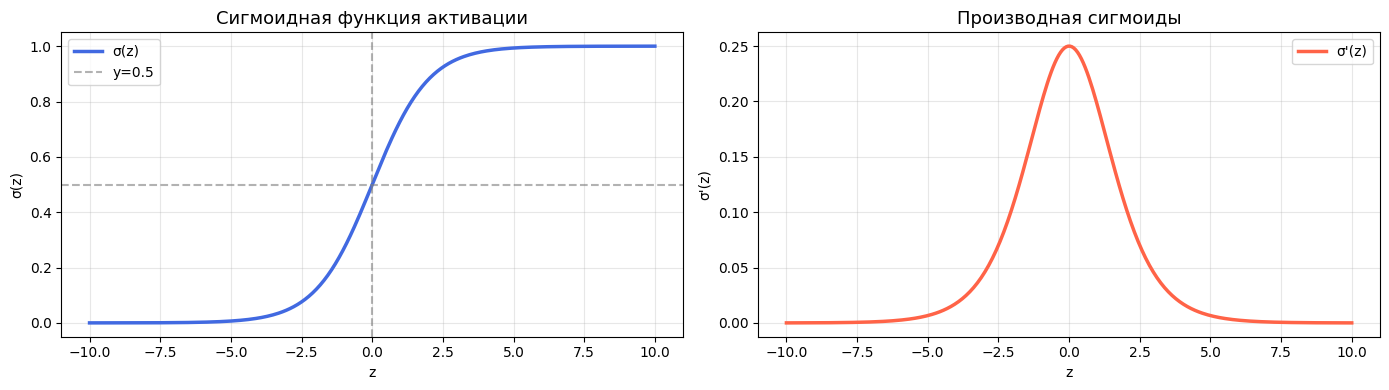

In [5]:
def sigmoid(z):
    """Сигмоидная функция: σ(z) = 1 / (1 + e^(-z))
    Область значений: (0, 1) — удобно для бинарной классификации.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(a):
    """Производная σ'(z) = σ(z) · (1 - σ(z))
    Принимает УЖЕ вычисленный σ(z) = a.
    """
    return a * (1.0 - a)

def softmax(z):
    """Softmax для многоклассовой классификации.
    softmax(z_i) = e^(z_i) / Σ e^(z_j)
    Вычитаем max для численной стабильности.
    """
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Визуализация сигмоиды
z = np.linspace(-10, 10, 300)
a = sigmoid(z)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(z, a, color='royalblue', linewidth=2.5, label='σ(z)')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='y=0.5')
axes[0].axvline(0,   color='gray', linestyle='--', alpha=0.6)
axes[0].set_title('Сигмоидная функция активации', fontsize=13)
axes[0].set_xlabel('z'); axes[0].set_ylabel('σ(z)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(z, sigmoid_derivative(a), color='tomato', linewidth=2.5, label="σ'(z)")
axes[1].set_title('Производная сигмоиды', fontsize=13)
axes[1].set_xlabel('z'); axes[1].set_ylabel("σ'(z)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Класс одиночного нейрона (Perceptron)

In [7]:
class SingleNeuron:
    """
    Один искусственный нейрон с сигмоидной активацией.
    """

    def __init__(self, n_features: int, lr: float = 0.1):
        self.lr = lr
        # Xavier-инициализация: уменьшает проблему исчезающих градиентов
        scale = np.sqrt(2.0 / n_features)
        self.w = np.random.randn(n_features, 1) * scale
        self.b = np.zeros((1, 1))
        self.loss_history = []

    def forward(self, X):
        """Прямой проход: z = Xw + b,  a = σ(z)"""
        self.X = X
        self.z = X @ self.w + self.b       # (m, 1)
        self.a = sigmoid(self.z)           # (m, 1)
        return self.a

    def compute_loss(self, y):
        """Binary Cross-Entropy Loss"""
        m = y.shape[0]
        eps = 1e-15
        a = np.clip(self.a, eps, 1 - eps)
        loss = -np.mean(y * np.log(a) + (1 - y) * np.log(1 - a))
        return loss

    def backward(self, y):
        """Обратный проход: вычисление градиентов и обновление весов"""
        m = y.shape[0]
        # Дельта выходного слоя: dL/dz = ŷ - y  (BCE + sigmoid упрощается)
        delta = self.a - y                 # (m, 1)
        # Градиенты
        dw = (self.X.T @ delta) / m        # (n_features, 1)
        db = np.mean(delta)                # scalar
        # Обновление весов (градиентный спуск)
        self.w -= self.lr * dw
        self.b -= self.lr * db

    def fit(self, X, y, epochs: int = 1000, verbose: int = 100):
        """Обучение нейрона на данных X, y"""
        y = y.reshape(-1, 1)
        self.loss_history = []
        for epoch in range(1, epochs + 1):
            self.forward(X)
            loss = self.compute_loss(y)
            self.loss_history.append(loss)
            self.backward(y)
            if verbose and epoch % verbose == 0:
                print(f'Epoch {epoch:5d}/{epochs} | Loss: {loss:.6f}')
        return self

    def predict_proba(self, X):
        return self.forward(X).flatten()

    def predict(self, X, threshold: float = 0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

### 1.3 Многослойная нейронная сеть (MLP)

In [8]:
class MLP:
    """
    Многослойный перцептрон произвольной архитектуры.

    Архитектура задаётся списком layer_sizes:
        [n_input, hidden1, hidden2, ..., n_output]

    Скрытые слои используют sigmoid-активацию.
    Выходной слой:
        - sigmoid  → бинарная классификация (BCE loss)
        - softmax  → многоклассовая классификация (CCE loss)
    """

    def __init__(self, layer_sizes: list, lr: float = 0.01,
                 output_mode: str = 'softmax'):
        """
        layer_sizes : список размеров слоёв, напр. [4, 10, 10, 3]
        lr          : learning rate
        output_mode : 'sigmoid' или 'softmax'
        """
        self.lr = lr
        self.output_mode = output_mode
        self.n_layers = len(layer_sizes) - 1  # кол-во весовых слоёв

        # Инициализация весов и смещений (Xavier)
        self.W = []
        self.b = []
        for i in range(self.n_layers):
            fan_in  = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            scale = np.sqrt(2.0 / fan_in)
            self.W.append(np.random.randn(fan_in, fan_out) * scale)
            self.b.append(np.zeros((1, fan_out)))

        self.loss_history = []

    def forward(self, X):
        """Прямой проход через все слои. Сохраняет активации для backprop."""
        self.activations = [X]          # a[0] = X
        a = X
        for l in range(self.n_layers):
            z = a @ self.W[l] + self.b[l]
            if l == self.n_layers - 1:
                # Выходной слой
                if self.output_mode == 'softmax':
                    a = softmax(z)
                else:
                    a = sigmoid(z)
            else:
                # Скрытый слой — sigmoid
                a = sigmoid(z)
            self.activations.append(a)
        return self.activations[-1]

    def compute_loss(self, y_true):
        """Categorical Cross-Entropy (или Binary CE)"""
        m = y_true.shape[0]
        a = np.clip(self.activations[-1], 1e-15, 1 - 1e-15)
        loss = -np.mean(np.sum(y_true * np.log(a), axis=1))
        return loss

    def backward(self, y_true):
        """Обратное распространение ошибки. Обновляет W и b всех слоёв."""
        m = y_true.shape[0]
        # Дельта выходного слоя (CE + softmax/sigmoid упрощается до ŷ - y)
        delta = self.activations[-1] - y_true   # (m, n_out)

        for l in reversed(range(self.n_layers)):
            a_prev = self.activations[l]         # (m, n_l)
            # Градиенты весов и смещений
            dW = (a_prev.T @ delta) / m          # (n_l, n_{l+1})
            db = np.mean(delta, axis=0, keepdims=True)
            # Градиент для предыдущего слоя (если не входной)
            if l > 0:
                delta_prev = (delta @ self.W[l].T) * sigmoid_derivative(a_prev)
            # Обновление весов (SGD)
            self.W[l] -= self.lr * dW
            self.b[l] -= self.lr * db
            if l > 0:
                delta = delta_prev

    def fit(self, X, y, epochs: int = 1000, verbose: int = 200):
        """Обучение сети. y — one-hot матрица (m, n_classes)."""
        self.loss_history = []
        for epoch in range(1, epochs + 1):
            self.forward(X)
            loss = self.compute_loss(y)
            self.loss_history.append(loss)
            self.backward(y)
            if verbose and epoch % verbose == 0:
                preds = self.predict(X)
                labels = np.argmax(y, axis=1)
                acc = accuracy_score(labels, preds)
                print(f'Epoch {epoch:5d}/{epochs} | Loss: {loss:.6f} | Train Acc: {acc:.4f}')
        return self

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

---
## Часть 2. Подготовка данных Iris

In [9]:
iris = load_iris()
X_full = iris.data           # (150, 4)
y_full = iris.target         # (150,)  0,1,2
feature_names = iris.feature_names
class_names   = iris.target_names

print('Форма данных:', X_full.shape)
print('Классы:', class_names)
print('Признаки:', feature_names)

# DataFrame для удобства
df = pd.DataFrame(X_full, columns=feature_names)
df['class'] = pd.Categorical.from_codes(y_full, class_names)
print('\nПервые 5 строк:')
df.head()

Форма данных: (150, 4)
Классы: ['setosa' 'versicolor' 'virginica']
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Первые 5 строк:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [10]:
# Для разделяющей линии берём только 2 признака (первые два: sepal length, sepal width)
# Для бинарной задачи берём классы 0 и 1 (setosa vs versicolor)

# ---  БИНАРНАЯ ВЫБОРКА (2 класса, 2 признака)  ---
mask_bin  = y_full < 2
X_bin_raw = X_full[mask_bin, :2]    # только первые 2 признака
y_bin     = y_full[mask_bin]        # 0 или 1

scaler_bin = StandardScaler()
X_bin = scaler_bin.fit_transform(X_bin_raw)

X_bin_tr, X_bin_te, y_bin_tr, y_bin_te = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

print(f'Бинарная выборка: train={X_bin_tr.shape}, test={X_bin_te.shape}')

# ---  МНОГОКЛАССОВАЯ ВЫБОРКА (3 класса, все 4 признака)  ---
scaler_mlp = StandardScaler()
X_mlp = scaler_mlp.fit_transform(X_full)

# One-hot encoding
def one_hot(y, n_classes):
    m = len(y)
    oh = np.zeros((m, n_classes))
    oh[np.arange(m), y] = 1
    return oh

y_oh = one_hot(y_full, 3)  # (150, 3)

X_mlp_tr, X_mlp_te, y_mlp_tr_oh, y_mlp_te_oh, y_mlp_tr, y_mlp_te = train_test_split(
    X_mlp, y_oh, y_full, test_size=0.2, random_state=42, stratify=y_full)

print(f'MLP выборка: train={X_mlp_tr.shape}, test={X_mlp_te.shape}')

Бинарная выборка: train=(80, 2), test=(20, 2)
MLP выборка: train=(120, 4), test=(30, 4)


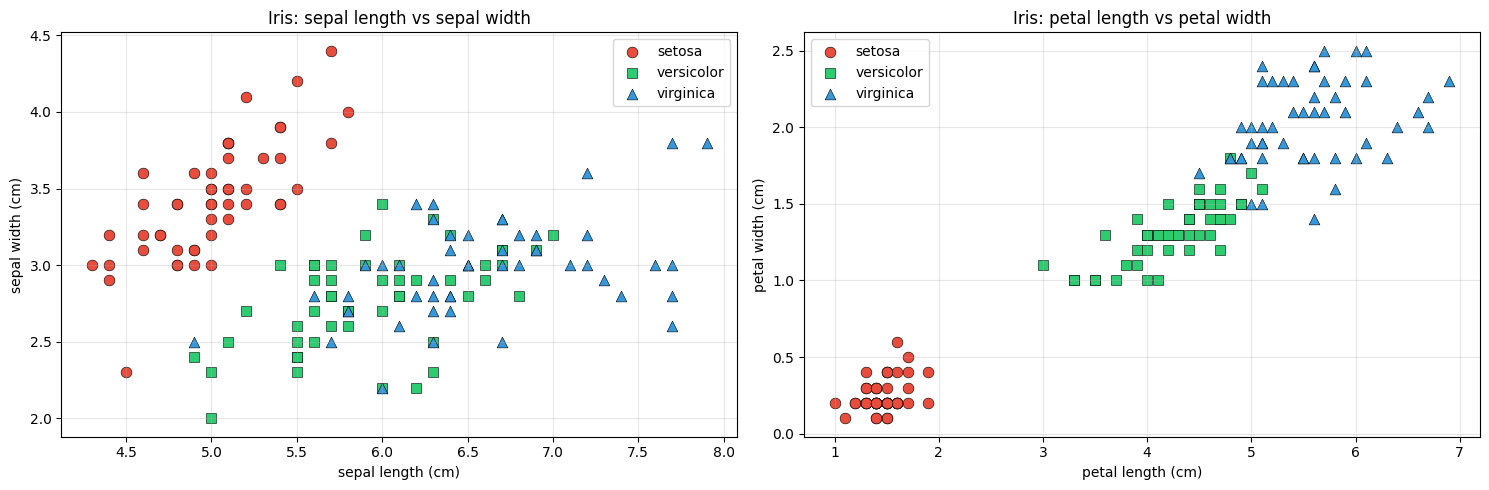

In [11]:
# Визуализация датасета Iris (первые 2 признака)
colors = ['#e74c3c', '#2ecc71', '#3498db']
markers = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for cls in range(3):
    mask = y_full == cls
    axes[0].scatter(X_full[mask, 0], X_full[mask, 1],
                    c=colors[cls], marker=markers[cls],
                    label=class_names[cls], s=60, edgecolors='k', linewidths=0.4)
axes[0].set_xlabel(feature_names[0]); axes[0].set_ylabel(feature_names[1])
axes[0].set_title('Iris: sepal length vs sepal width')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for cls in range(3):
    mask = y_full == cls
    axes[1].scatter(X_full[mask, 2], X_full[mask, 3],
                    c=colors[cls], marker=markers[cls],
                    label=class_names[cls], s=60, edgecolors='k', linewidths=0.4)
axes[1].set_xlabel(feature_names[2]); axes[1].set_ylabel(feature_names[3])
axes[1].set_title('Iris: petal length vs petal width')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Часть 3. Модель 1 — Один нейрон (бинарная классификация)

In [12]:
neuron = SingleNeuron(n_features=2, lr=0.5)
neuron.fit(X_bin_tr, y_bin_tr, epochs=2000, verbose=400)

Epoch   400/2000 | Loss: 0.021290
Epoch   800/2000 | Loss: 0.013285
Epoch  1200/2000 | Loss: 0.010035
Epoch  1600/2000 | Loss: 0.008197
Epoch  2000/2000 | Loss: 0.006992


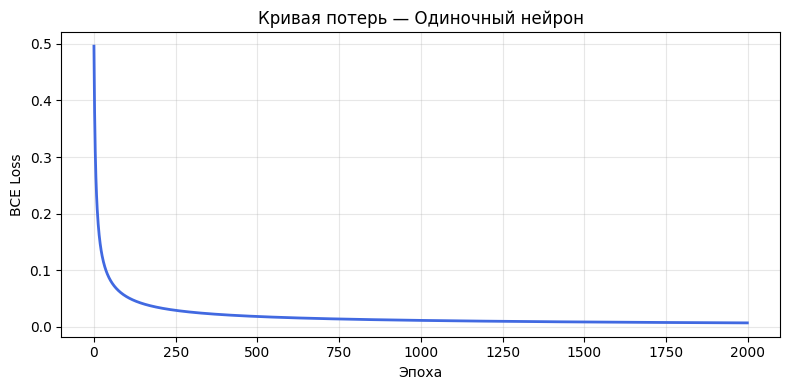

In [13]:
# Кривая обучения
plt.figure(figsize=(8, 4))
plt.plot(neuron.loss_history, color='royalblue', linewidth=2)
plt.xlabel('Эпоха'); plt.ylabel('BCE Loss')
plt.title('Кривая потерь — Одиночный нейрон')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
y_pred_neuron_tr = neuron.predict(X_bin_tr)
y_pred_neuron_te = neuron.predict(X_bin_te)

def print_metrics(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f'\n{name}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-score  : {f1:.4f}')
    return acc, prec, rec, f1

m1_tr = print_metrics(y_bin_tr, y_pred_neuron_tr, 'Нейрон | Train')
m1_te = print_metrics(y_bin_te, y_pred_neuron_te, 'Нейрон | Test')

print('\nClassification Report (Test):')
print(classification_report(y_bin_te, y_pred_neuron_te,
      target_names=class_names[:2]))


Нейрон | Train
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-score  : 1.0000

Нейрон | Test
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-score  : 1.0000

Classification Report (Test):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



---
## Часть 4. Модель 2 — MLP (2 слоя × 10 нейронов)

In [16]:
#  МОДЕЛЬ 2: MLP — 2 скрытых слоя по 10 нейронов
#  Архитектура: [4] → [10] → [10] → [3]
#  Все 3 класса Iris, все 4 признака

mlp = MLP(layer_sizes=[4, 10, 10, 3], lr=0.05, output_mode='softmax')
mlp.fit(X_mlp_tr, y_mlp_tr_oh, epochs=3000, verbose=500)

Epoch   500/3000 | Loss: 0.492148 | Train Acc: 0.8917
Epoch  1000/3000 | Loss: 0.300061 | Train Acc: 0.9500
Epoch  1500/3000 | Loss: 0.190169 | Train Acc: 0.9583
Epoch  2000/3000 | Loss: 0.129512 | Train Acc: 0.9667
Epoch  2500/3000 | Loss: 0.098903 | Train Acc: 0.9750
Epoch  3000/3000 | Loss: 0.082330 | Train Acc: 0.9750


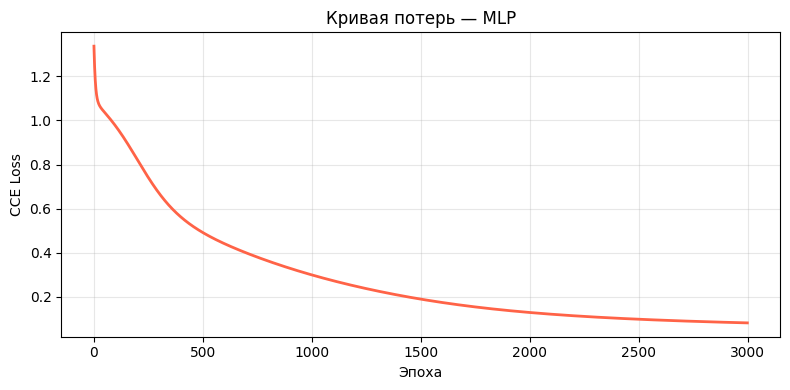

In [17]:
# Кривая обучения MLP
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_history, color='tomato', linewidth=2)
plt.xlabel('Эпоха'); plt.ylabel('CCE Loss')
plt.title('Кривая потерь — MLP')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Метрики MLP
y_pred_mlp_tr = mlp.predict(X_mlp_tr)
y_pred_mlp_te = mlp.predict(X_mlp_te)

m2_tr = print_metrics(y_mlp_tr, y_pred_mlp_tr, 'MLP | Train')
m2_te = print_metrics(y_mlp_te, y_pred_mlp_te, 'MLP | Test')

print('\nClassification Report (Test):')
print(classification_report(y_mlp_te, y_pred_mlp_te,
      target_names=class_names))


MLP | Train
  Accuracy  : 0.9750
  Precision : 0.9752
  Recall    : 0.9750
  F1-score  : 0.9750

MLP | Test
  Accuracy  : 0.9333
  Precision : 0.9333
  Recall    : 0.9333
  F1-score  : 0.9333

Classification Report (Test):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



---
## Часть 5. Разделяющие линии (Decision Boundary)

In [19]:
def plot_decision_boundary(model, X, y, title,
                           scaler=None, ax=None,
                           is_single_neuron=False):
    """Рисует decision boundary для 2D пространства признаков."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Координатная сетка
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Предсказания на сетке
    if is_single_neuron:
        Z = model.predict(grid)
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    # Заливка регионов
    cmap_bg = mcolors.ListedColormap(['#FADADD', '#D5F5E3', '#D6EAF8'])
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.8, alpha=0.5)

    # Точки данных
    colors_pts = ['#e74c3c', '#2ecc71', '#3498db']
    unique_labels = np.unique(y)
    for i, cls in enumerate(unique_labels):
        mask = y == cls
        label = class_names[cls] if cls < len(class_names) else str(cls)
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=colors_pts[i % 3], edgecolors='k',
                   linewidths=0.4, s=60, label=label, zorder=5)

    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
    return ax

print('Функция plot_decision_boundary определена.')

Функция plot_decision_boundary определена.


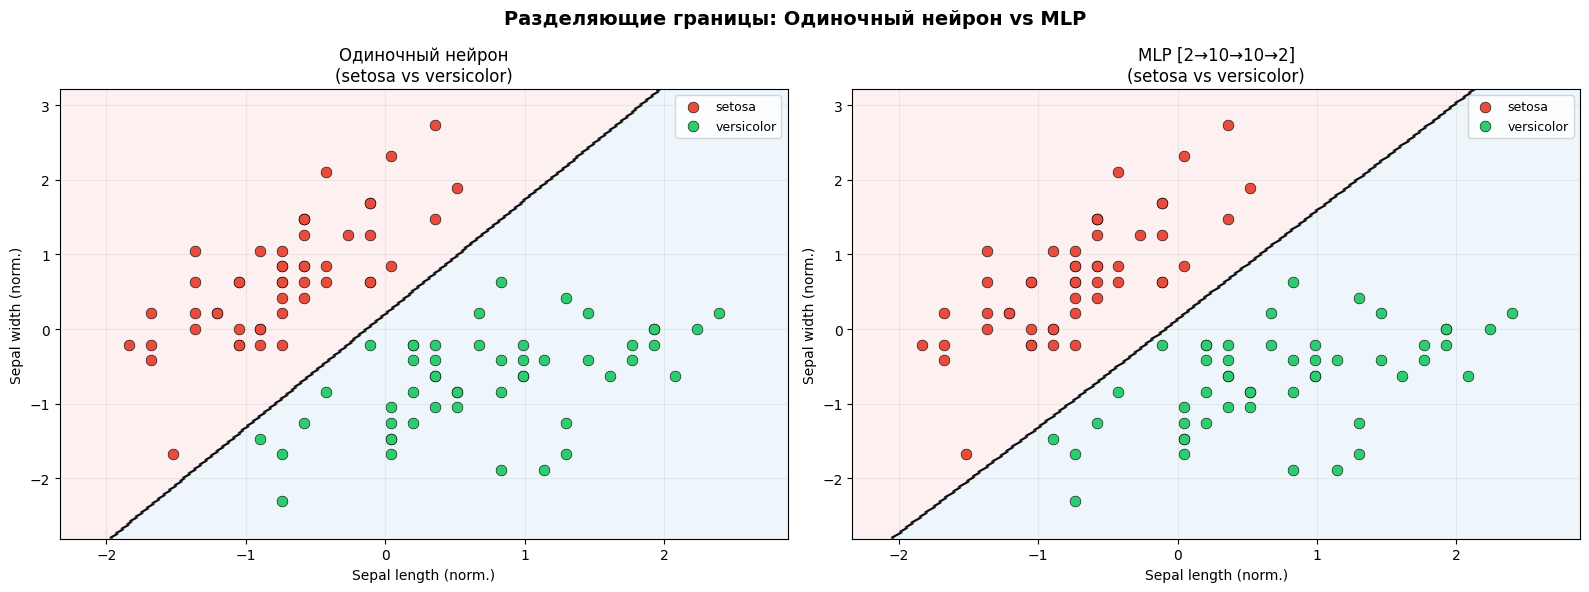

In [21]:
# =========================================================
#  МОДЕЛЬ 1: Разделяющая линия одиночного нейрона
#  (бинарная задача, 2 признака: уже нормализованы)
# =========================================================

# MLP для 2D-визуализации бинарной задачи тоже обучим
# Для честного сравнения — обе модели на тех же 2D данных
mlp_2d = MLP(layer_sizes=[2, 10, 10, 2], lr=0.05, output_mode='softmax')
y_bin_oh = one_hot(y_bin_tr, 2)
mlp_2d.fit(X_bin_tr, y_bin_oh, epochs=2000, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundary(
    neuron, np.vstack([X_bin_tr, X_bin_te]),
    np.concatenate([y_bin_tr, y_bin_te]),
    title='Одиночный нейрон\n(setosa vs versicolor)',
    ax=axes[0], is_single_neuron=True
)
axes[0].set_xlabel('Sepal length (norm.)'); axes[0].set_ylabel('Sepal width (norm.)')

plot_decision_boundary(
    mlp_2d, np.vstack([X_bin_tr, X_bin_te]),
    np.concatenate([y_bin_tr, y_bin_te]),
    title='MLP [2→10→10→2]\n(setosa vs versicolor)',
    ax=axes[1]
)
axes[1].set_xlabel('Sepal length (norm.)'); axes[1].set_ylabel('Sepal width (norm.)')

plt.suptitle('Разделяющие границы: Одиночный нейрон vs MLP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

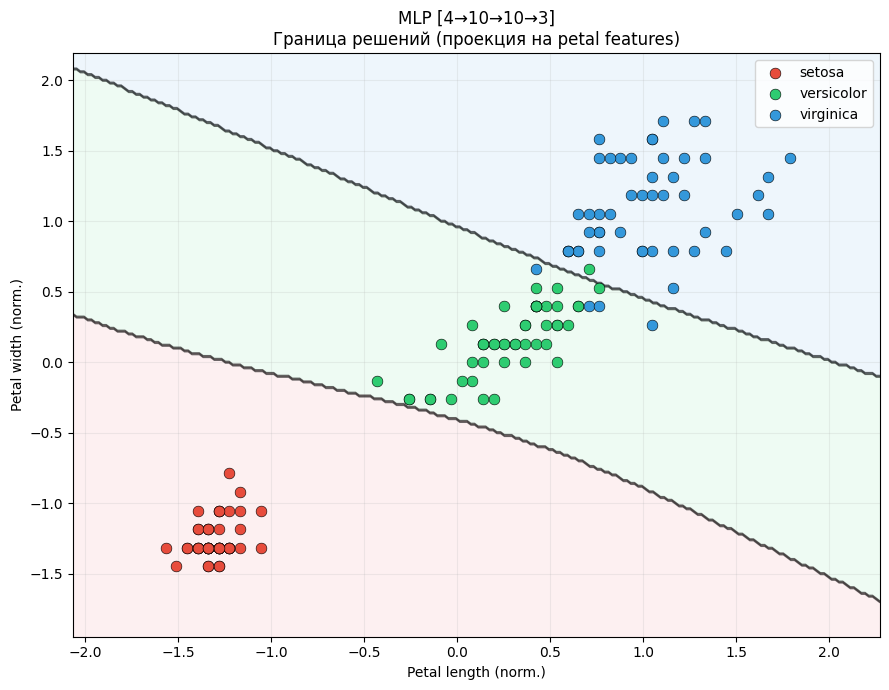

In [23]:
# Для MLP (4 признака, 3 класса) строим границу в плоскости petal length vs petal width
# Фиксируем первые 2 признака на их средних значениях

x_min, x_max = X_mlp[:, 2].min() - 0.5, X_mlp[:, 2].max() + 0.5
y_min, y_max = X_mlp[:, 3].min() - 0.5, X_mlp[:, 3].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

mean_feat01 = X_mlp[:, :2].mean(axis=0)
grid_4d = np.c_[
    np.full(xx.ravel().shape, mean_feat01[0]),
    np.full(xx.ravel().shape, mean_feat01[1]),
    xx.ravel(),
    yy.ravel()
]

Z = mlp.predict(grid_4d).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
cmap_bg = mcolors.ListedColormap(['#FADADD', '#D5F5E3', '#D6EAF8'])
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
ax.contour(xx, yy, Z, colors='k', linewidths=0.8, alpha=0.5)

colors_pts = ['#e74c3c', '#2ecc71', '#3498db']
for cls in range(3):
    mask = y_full == cls
    ax.scatter(X_mlp[mask, 2], X_mlp[mask, 3],
               c=colors_pts[cls], edgecolors='k', linewidths=0.4,
               s=60, label=class_names[cls], zorder=5)

ax.set_xlabel('Petal length (norm.)'); ax.set_ylabel('Petal width (norm.)')
ax.set_title('MLP [4→10→10→3]\nГраница решений (проекция на petal features)', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## Часть 6. Сравнение метрик

In [24]:
# MLP на 2D-данных
y_pred_mlp2d_te = mlp_2d.predict(X_bin_te)
m3_te = print_metrics(y_bin_te, y_pred_mlp2d_te, 'MLP 2D | Test')

# Таблица сравнения
print('\n' + '='*65)
print(f'{"Модель":<30} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-'*65)

# Нейрон (тест)
a,p,r,f = m1_te
print(f'{"Нейрон (test, бинарная)":<30} {a:>9.4f} {p:>10.4f} {r:>8.4f} {f:>8.4f}')

# MLP 2D (тест)
a,p,r,f = m3_te
print(f'{"MLP 2D (test, бинарная)":<30} {a:>9.4f} {p:>10.4f} {r:>8.4f} {f:>8.4f}')

# MLP 4D (тест)
a,p,r,f = m2_te
print(f'{"MLP 4D (test, 3 класса)":<30} {a:>9.4f} {p:>10.4f} {r:>8.4f} {f:>8.4f}')
print('='*65)


MLP 2D | Test
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-score  : 1.0000

Модель                          Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
Нейрон (test, бинарная)           1.0000     1.0000   1.0000   1.0000
MLP 2D (test, бинарная)           1.0000     1.0000   1.0000   1.0000
MLP 4D (test, 3 класса)           0.9333     0.9333   0.9333   0.9333


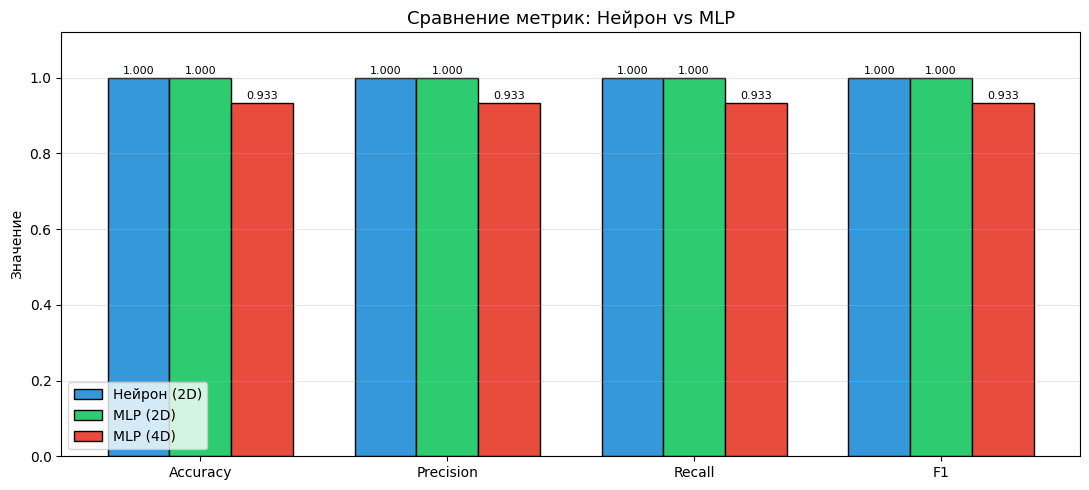

In [25]:
# Визуализация сравнения метрик
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
neuron_scores = list(m1_te)
mlp2d_scores  = list(m3_te)
mlp4d_scores  = list(m2_te)

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width, neuron_scores, width, label='Нейрон (2D)', color='#3498db', edgecolor='k')
bars2 = ax.bar(x,         mlp2d_scores,  width, label='MLP (2D)',    color='#2ecc71', edgecolor='k')
bars3 = ax.bar(x + width, mlp4d_scores,  width, label='MLP (4D)',    color='#e74c3c', edgecolor='k')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(0, 1.12)
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylabel('Значение'); ax.set_title('Сравнение метрик: Нейрон vs MLP', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

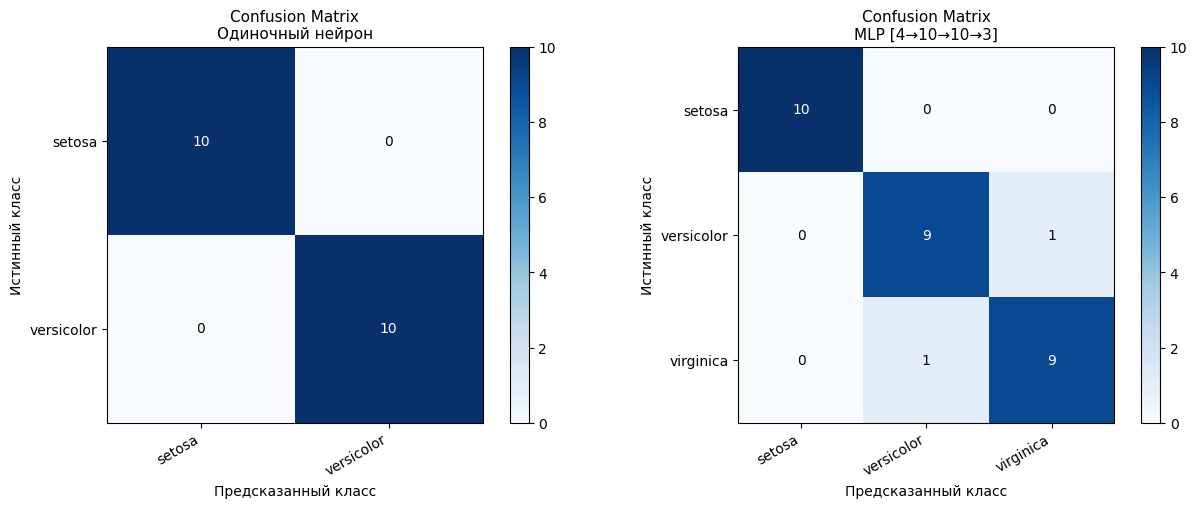

In [26]:
# Матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def plot_cm(ax, y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=11)
    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks); ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_yticks(tick_marks); ax.set_yticklabels(labels)
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')
    plt.colorbar(im, ax=ax)

plot_cm(axes[0], y_bin_te, y_pred_neuron_te,
        class_names[:2], 'Confusion Matrix\nОдиночный нейрон')
plot_cm(axes[1], y_mlp_te, y_pred_mlp_te,
        class_names, 'Confusion Matrix\nMLP [4→10→10→3]')

plt.tight_layout()
plt.show()

---
## Выводы

1. **Одиночный нейрон** — реализует линейную разделяющую границу. Отлично справляется с линейно разделимыми классами (setosa хорошо отделяется по sepal-признакам). Граница — прямая линия в 2D.

2. **MLP [4→10→10→3]** — нелинейная граница благодаря скрытым слоям. Решает все 3 класса Iris с высокой точностью, используя все 4 признака.

3. **Backpropagation** корректно вычисляет градиенты по всем слоям через цепное правило, градиентный спуск обновляет веса в направлении убывания функции потерь.

4. **Ключевые отличия**: глубокая сеть значительно мощнее одного нейрона — способна аппроксимировать произвольные нелинейные границы, но требует больше данных и аккуратной настройки гиперпараметров.